In [ ]:
# IN ORDER TO SEND THE NOTEBOOKS AS AN ATTACHMENT, WE REMOVED SOME OUTPUTS THAT CAN BE FOUND EITHER IN THE CUSTOMMODEL OR IN THE DENSENET121 NOTEBOOKS AS THEY WERE IDENTICAL

## 🌐 **Google Drive Connection**

In [1]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive/[2025-2026]\\ AN2DL/Challenge\\ 2"
%cd $current_dir

Mounted at /gdrive
/gdrive/.shortcut-targets-by-id/1VvyqcN2puDvQNayGrJZr2BIZV4fbj35l/Challenge 2


## ⚙️ **Libraries Import**

In [2]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
import torchvision.transforms.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

# For synchronized augmentation of images and masks
import albumentations as A

# Install and import torchview for model visualisation
!pip install -q torchview
from torchview import draw_graph

# Configure device and set seeds for CUDA if available
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")

# Setup directories for models and logs
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import csv
import scipy
from PIL import Image
from xml.dom import minidom
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cu126
Device: cuda


## ⏳ **Data Loading**

In [3]:
# ================================
# Train Dataset
# ================================

# Set environment variables for train dataset
os.environ["TRAIN_ZIP_NAME"] = "train_data.zip"
os.environ["TRAIN_ZIP_ID"]   = "1FQd64ACO4fk--qW4J5wuVSX4sr5kBdSK"

# Check if train dataset exists, download and unzip if not
if not os.path.exists(f"/content/{os.environ['TRAIN_ZIP_NAME']}"):
    print("Downloading train_data.zip...")
    !gdown -q ${TRAIN_ZIP_ID} -O /content/${TRAIN_ZIP_NAME}
    print("train_data.zip downloaded!")

    print("Unzipping train_data.zip...")
    !unzip -qo /content/${TRAIN_ZIP_NAME} -d /content/
    print("train_data unzipped!")
else:
    print("train_data.zip already downloaded and unzipped. Using cached data.")


# ================================
# Test Dataset
# ================================

# Set environment variables for test dataset
os.environ["TEST_ZIP_NAME"] = "test_data.zip"
os.environ["TEST_ZIP_ID"]   = "1gOwuQf-4Xm0YTAHidqy28UYyvOCm6BkA"

# Check if test dataset exists, download and unzip if not
if not os.path.exists(f"/content/{os.environ['TEST_ZIP_NAME']}"):
    print("Downloading test_data.zip...")
    !gdown -q ${TEST_ZIP_ID} -O /content/${TEST_ZIP_NAME}
    print("test_data.zip downloaded!")

    print("Unzipping test_data.zip...")
    !unzip -qo /content/${TEST_ZIP_NAME} -d /content/
    print("test_data unzipped!")
else:
    print("test_data.zip already downloaded and unzipped. Using cached data.")

# ================================
# Labels
# ================================

# Import
labels = pd.read_csv('train_labels.csv')

# Create a column with the numeric labels
labels["label_numeric"] = labels["label"].astype("category").cat.codes

# Create the mapping
int_to_label = dict(enumerate(labels["label"].astype("category").cat.categories))

train_data.zip downloaded!
Unzipping train_data.zip...
train_data unzipped!
test_data.zip downloaded!
Unzipping test_data.zip...
test_data unzipped!


In [4]:
IMG_SIZE = 256
def extract_index(filename):
    return filename.split("_")[1].split(".")[0]


def load_images_from_folder(folder):
    """
    Load images and masks from a folder.
    Masks are recognized by filename starting with 'mask'.

    Returns:
        images: np.ndarray (N, 224,224,3)
        masks:  np.ndarray (N, 224,224,1) or empty array if none found
    """
    images_dictionary = {}
    masks_dictionary = {}

    # Iterate through files in the specified folder
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))

        if img is None:
            continue

        idx = extract_index(filename)

        # MASK
        if filename.lower().startswith("mask"):
            # If mask is RGB, take only one channel
            if len(img.shape) == 3:
                img = img[..., 0]

            # Resize using nearest neighbor
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

            # Expand to (H, W, 1)
            img = img[:, :, None].astype(np.float32)

            masks_dictionary[idx] = img

        # IMAGE
        elif filename.lower().startswith("img"):
            # Normalize image pixel values to a float range [0, 1]
            img = img.astype(np.float32)

            # Convert image from BGR to RGB
            if img.shape[-1] == 3:
                img = img[..., ::-1]

            # Resize the image to 224x224 pixels
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            images_dictionary[idx] = img

    # Sanity check
    assert sorted(images_dictionary.keys()) == sorted(masks_dictionary.keys())

    keys = sorted(images_dictionary.keys())
    images = np.array([images_dictionary[k] for k in keys])
    masks = np.array([masks_dictionary[k] for k in keys])

    return images, masks

In [5]:
train_path = '/content/train_data/'
train_images, train_masks = load_images_from_folder(train_path)

test_path = '/content/test_data/'
test_images, test_masks = load_images_from_folder(test_path)

In [6]:
print(f"Train images shape: {train_images.shape}")
print(f"Train mask shape: {train_masks.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test masks shape: {test_masks.shape}")
print(f"Labels shape: {labels.shape}")

Train images shape: (691, 256, 256, 3)
Train mask shape: (691, 256, 256, 1)
Test images shape: (477, 256, 256, 3)
Test masks shape: (477, 256, 256, 1)
Labels shape: (691, 3)


## 🔎 **Exploration and Data Analysis**

In [7]:
def display_image(idx, axes=None):
    """
    Display image, mask, and overlay for a single ID.
    If axes are provided, draw into them (3 axes vertically).
    Otherwise, create and show a standalone figure.
    """
    idx = min(idx, len(train_images) - 1)
    img = train_images[idx] / 255.0
    mask = train_masks[idx].squeeze() / 255.0

    # Case 1: called alone → create its own figure
    if axes is None:
        fig, axes = plt.subplots(3, 1, figsize=(6,12))

    # Image
    axes[0].imshow(img)
    axes[0].set_title(f"Image {idx}")
    axes[0].axis("off")

    # Mask
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(f"Mask {idx}")
    axes[1].axis("off")

    # Overlay
    axes[2].imshow(img)
    axes[2].imshow(mask, cmap="jet", alpha=0.35)
    axes[2].set_title(f"Overlay {idx}")
    axes[2].axis("off")

    # Show only when standalone
    if axes is None:
        plt.tight_layout()


In [ ]:
display_image(1145)

In [9]:
def display_images_with_masks(num_img=5):
    num_img = min(num_img, len(train_images))

    fig, axes = plt.subplots(3, num_img, figsize=(4*num_img, 12))

    for i in range(num_img):
        col_axes = axes[:, i]
        display_image(i, axes=col_axes)

    plt.tight_layout()
    plt.show()


In [ ]:
display_images_with_masks()

In [11]:
labels_numeric = labels["label_numeric"].values

print("\nClass distribution:")
for class_idx, class_name in int_to_label.items():
    count = np.sum(labels_numeric == class_idx)
    print(f"  {class_name}: {count} images ({count/len(labels_numeric)*100:.1f}%)")



Class distribution:
  HER2(+): 189 images (27.4%)
  Luminal A: 205 images (29.7%)
  Luminal B: 220 images (31.8%)
  Triple negative: 77 images (11.1%)


##**🧹Pulizia**

In [12]:
def detect_cartoon_image_hsv(
    img,
    min_frac_area=0.003,    # minimum fraction of area of image covered in neon green
    min_pixels=1500         # minimum number of pixels in neon green
):
    """
    detects overlay  Shrek/slime using HSV + connected area.
    img: np.array (H, W, 3) in [0,1] RGB
    """
    H, W, _ = img.shape
    total = H * W

    # Convert in HSV (uint8, 0-255)
    img8 = (img).astype(np.uint8)
    hsv  = cv2.cvtColor(img8, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    # Range for green:
    green_mask = (
        (h >= 40) & (h <= 90) &  # green hue
        (s >= 150) &             # high saturation
        (v >= 120)               # quite high brightness
    ).astype(np.uint8)

    # Look for the highest of the connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        green_mask, connectivity=8
    )

    # stats[0] = background, the others are the components
    max_area = 0
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > max_area:
            max_area = area

    frac_area = max_area / total

    is_cartoon = (max_area >= min_pixels) or (frac_area >= min_frac_area)
    return is_cartoon, frac_area, max_area


In [13]:
def is_shrek(img, thr=0.05):
    """
    img: a single image of the dataset, (224,224,3) RGB [0,255]
    """
    img_uint8 = img.astype(np.uint8)

    # Convert RGB → BGR (opencv)
    img_bgr = img_uint8[:, :, ::-1]

    # Convert HSV
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    hue        = hsv[:, :, 0]
    saturation = hsv[:, :, 1]
    value      = hsv[:, :, 2]

    # Mask cartoon colours (Shrek)
    mask = (
        (hue >= 10) & (hue <= 40) &
        (saturation >= 120) &
        (value >= 40) & (value <= 200)
    )

    ratio = np.mean(mask)
    return ratio > thr, ratio


In [14]:
def sensible_detection(img, min_pixels=20):
    """
    Detects Shrek even when there are few strange pixels
    img: array (H,W,3) in [0,255], RGB
    """
    img8 = img.astype(np.uint8)
    hsv = cv2.cvtColor(img8, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    # Green neon Shrek
    green = (
        (h >= 35) & (h <= 100) &
        (s >= 90) &
        (v >= 80)
    )

    # Orange Shrek
    orange = (
        (h >= 5) & (h <= 35) &
        (s >= 80) &
        (v >= 80)
    )

    mask = green | orange
    suspicious = np.count_nonzero(mask)

    return suspicious >= min_pixels, suspicious


In [ ]:
cartoon_idx = []
normal_idx  = []

for i, img in enumerate(train_images):
    flag, frac_area, max_area = detect_cartoon_image_hsv(img)
    if flag:
        cartoon_idx.append(i)
    else:
        normal_idx.append(i)

print(f"Cartoon images: {len(cartoon_idx)} / {len(train_images)}")
print("Some cartoon indices:", cartoon_idx[:20])

for i in cartoon_idx[:]:
    plt.figure()
    plt.title(f"Candidate cartoon idx {i}")
    plt.imshow(train_images[i]/255)
    plt.axis("off")
    plt.show()

In [ ]:
shrek_indices_train = []
shrek_ratios_train = []

for i, img in enumerate(train_images):
    flag, ratio = is_shrek(img)
    if flag:
        shrek_indices_train.append(i)
        shrek_ratios_train.append(ratio)

print(f"\nFound {len(shrek_indices_train)} Shrek images in the training set")
print("Found indexes:", shrek_indices_train)

for idx, ratio in zip(shrek_indices_train, shrek_ratios_train):
    plt.figure(figsize=(5,5))
    plt.imshow(train_images[idx]/255.0)
    plt.title(f"TRAIN idx {idx}  |  cartoon_ratio = {ratio:.3f}")
    plt.axis("off")
    plt.show()

In [ ]:
sensible_indices = []
sensible_pixelcounts = []

for i, img in enumerate(train_images):
    flag, suspicious_pixels = sensible_detection(img)
    if flag:
        sensible_indices.append(i)
        sensible_pixelcounts.append(suspicious_pixels)

print(f"\nFound {len(sensible_indices)} sensible images in the training set.")
print("Found indexes:", sensible_indices)

# plot all the images found
for idx, suspicious_pixels in zip(sensible_indices, sensible_pixelcounts):
    plt.figure(figsize=(5,5))
    plt.imshow(train_images[idx] / 255.0)   # le immagini sono in [0,255]
    plt.title(f"TRAIN idx {idx}  |  suspicious_pixels = {suspicious_pixels}")
    plt.axis("off")
    plt.show()


In [18]:
to_remove = set(cartoon_idx) | set(shrek_indices_train) | set(sensible_indices)
print("Total number of images to remove:", len(to_remove))

all_indices = set(range(len(train_images)))
keep_idx = sorted(list(all_indices - to_remove))

print("Number of remaining images:", len(keep_idx))

train_images_clean = train_images[keep_idx]
train_masks_clean  = train_masks[keep_idx]
labels_clean       = labels["label_numeric"].values[keep_idx]

train_images = train_images_clean
train_masks  = train_masks_clean
labels_numeric = labels_clean

Total number of images to remove: 111
Number of remaining images: 580


##**⚖️ Class Imbalance**

In [19]:
train_images_base   = train_images.copy()
train_masks_base    = train_masks.copy()
labels_numeric_base = labels_numeric.copy()


In [20]:
train_images   = train_images_base
train_masks    = train_masks_base
labels_numeric = labels_numeric_base

# oversampling:
idx_tn = np.where(labels_numeric_base == 3)[0]
print("Original Triple negative:", len(idx_tn))

k = 1 # number of repeats
idx_tn_rep = np.repeat(idx_tn, k)

Train_extra = train_images_base[idx_tn_rep]
M_extra     = train_masks_base[idx_tn_rep]
label_extra = labels_numeric_base[idx_tn_rep]

train_images   = np.concatenate([train_images_base, Train_extra], axis=0)
train_masks    = np.concatenate([train_masks_base,  M_extra], axis=0)
labels_numeric = np.concatenate([labels_numeric_base, label_extra], axis=0)

print("After oversampling:")
print("  train_images:", train_images.shape)
print("  train_masks: ", train_masks.shape)
print("  labels_numeric:", labels_numeric.shape)

tn_after = np.sum(labels_numeric == 3)
print("Triple negative AFTER oversampling:", tn_after)

Original Triple negative: 69
After oversampling:
  train_images: (649, 256, 256, 3)
  train_masks:  (649, 256, 256, 1)
  labels_numeric: (649,)
Triple negative AFTER oversampling: 138


In [ ]:
# Calculates counts per class
class_indices = list(int_to_label.keys())
class_names = [int_to_label[i] for i in class_indices]
counts = [np.sum(labels_numeric == i) for i in class_indices]

# Plot
plt.figure(figsize=(7, 4))
plt.bar(class_names, counts)
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##**⏫️ Data Augmentation**


In [22]:
def simple_augmentation(img, mask):

    # Random horizontal flip
    if random.random() > 0.5:
        img = torchvision.transforms.functional.hflip(img)
        mask = torchvision.transforms.functional.hflip(mask)

    # Random vertical flip
    if random.random() > 0.5:
        img = torchvision.transforms.functional.vflip(img)
        mask = torchvision.transforms.functional.vflip(mask)

    # Random rotation (solo 90°, 180°, 270°)
    if random.random() > 0.5:
        angle = random.choice([90, 180, 270])
        img = torchvision.transforms.functional.rotate(
            img, angle,
            interpolation=torchvision.transforms.InterpolationMode.BILINEAR
        )
        mask = torchvision.transforms.functional.rotate(
            mask, angle,
            interpolation=torchvision.transforms.InterpolationMode.NEAREST
        )

    # Leggero color jitter (SOLO sull'immagine)
    if random.random() > 0.5:
        img = torchvision.transforms.functional.adjust_brightness(img, random.uniform(0.9, 1.1))
    if random.random() > 0.5:
        img = torchvision.transforms.functional.adjust_contrast(img, random.uniform(0.9, 1.1))

    return img.clamp(0, 1), mask.clamp(0, 1)



##**🧩Patching**

In [23]:
def detect_tissue_from_image(image, gray_threshold=0.95, std_threshold=0.02):
    """
    Detect tissue regions in histology image (non-background areas).
    Works for images with tissue on gray/black background.

    Args:
        image: numpy array (H, W, 3) normalized [0,1]
        gray_threshold: threshold for gray background (tissue is LESS gray)
        std_threshold: minimum color variation (tissue has more color)

    Returns:
        Binary mask (H, W) where True = tissue
    """
    # Detect background by LACK of color variation
    # Background is gray/uniform, tissue has purple/pink colors

    # Calculate standard deviation across RGB channels: background (gray) has std ≈ 0, tissue (colored) has std > 0
    color_std = np.std(image, axis=2)

    # Also check if pixels are too dark (black background) or too light (white)
    gray = np.mean(image, axis=2)

    # Tissue = has color variation OR is in mid-range gray
    tissue_mask = (color_std > std_threshold) | ((gray > 0.15) & (gray < gray_threshold))

    # Clean up with morphological operations
    kernel = np.ones((7, 7), np.uint8)
    tissue_mask = cv2.morphologyEx(tissue_mask.astype(np.uint8),
                                    cv2.MORPH_CLOSE, kernel)
    tissue_mask = cv2.morphologyEx(tissue_mask, cv2.MORPH_OPEN, kernel)

    return tissue_mask.astype(bool)

In [24]:
def extract_patches_hybrid(image, annotation_mask, patch_size=128, stride=64,
                           min_tissue_ratio=0.10, mask_overlap_bonus=2.0):
    """
    HYBRID APPROACH: Extract patches from entire tissue BUT prioritize
    patches that overlap with annotation mask.

    Args:
        image: numpy array (H, W, 3) normalized [0,1]
        annotation_mask: numpy array (H, W, 1) - small annotated region [0,1]
        patch_size: size of square patches
        stride: stride between patches
        min_tissue_ratio: minimum fraction of tissue required (LOWERED to 0.15)
        mask_overlap_bonus: weight multiplier for patches overlapping annotation

    Returns:
        patches: List of patch arrays
        weights: List of sampling weights (higher = more important)
        has_annotation: List of bools (True if patch overlaps annotation)
    """
    H, W, _ = image.shape
    patches = []
    mask_patches=[]
    weights = []
    has_annotation = []

    # Detect all tissue
    tissue_mask = detect_tissue_from_image(image)

    # Binary annotation mask
    annotation_binary = (annotation_mask.squeeze() > 0.1).astype(bool)

    # Sliding window over entire image
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            # Extract patch region masks
            patch_tissue = tissue_mask[y:y+patch_size, x:x+patch_size]
            patch_annotation = annotation_binary[y:y+patch_size, x:x+patch_size]

            # Check if patch has enough tissue
            tissue_ratio = patch_tissue.sum() / (patch_size * patch_size)

            if tissue_ratio >= min_tissue_ratio:
                # Extract the actual image patch
                patch = image[y:y+patch_size, x:x+patch_size, :]
                patch_mask=annotation_mask[y:y+patch_size, x:x+patch_size, :]

                patches.append(patch)
                mask_patches.append(patch_mask)

                # Calculate importance weight
                annotation_ratio = patch_annotation.sum() / (patch_size * patch_size)

                if annotation_ratio > 0:
                    # This patch overlaps with annotation - boost its weight
                    weight = 1.0 + (mask_overlap_bonus * annotation_ratio)
                    has_annotation.append(True)
                else:
                    # Normal tissue patch
                    weight = 1.0
                    has_annotation.append(False)

                weights.append(weight)

    return patches, weights, has_annotation, mask_patches

##**🏷 Mixup**

In [25]:
def generate_mixup_samples(images, masks, labels_onehot,
                          mixup_samples_per_image=1,
                          alpha=1.0):
    """Generates blended samples"""

    N = len(images)
    num_classes = labels_onehot.shape[1]

    images_mixed = []
    masks_mixed = []
    labels_mixed = []

    print(f"\n{'='*70}")
    print(f"GENERATING MIXUP SAMPLES")
    print(f"{'='*70}")
    print(f"Original images: {N}")
    print(f"Mixup samples per image: {mixup_samples_per_image}")
    print(f"Target total images: {N * (1 + mixup_samples_per_image)}")
    print(f"{'='*70}\n")

    # Keep originals
    images_mixed.append(images)
    masks_mixed.append(masks)
    labels_mixed.append(labels_onehot.astype(np.float32))

    # Generates mixup
    for mix_idx in range(mixup_samples_per_image):
        print(f"Generating mixup batch {mix_idx + 1}/{mixup_samples_per_image}...")

        mixed_images_batch = []
        mixed_masks_batch = []
        mixed_labels_batch = []

        for i in range(N):
            j = np.random.randint(0, N)
            while j == i:
                j = np.random.randint(0, N)

            lam = np.random.beta(alpha, alpha)
            lam = max(lam, 1 - lam)

            mixed_image = lam * images[i] + (1 - lam) * images[j]
            mixed_mask = lam * masks[i] + (1 - lam) * masks[j]
            label_soft = lam * labels_onehot[i] + (1 - lam) * labels_onehot[j]

            mixed_images_batch.append(mixed_image.astype(np.float32))
            mixed_masks_batch.append(mixed_mask.astype(np.float32))
            mixed_labels_batch.append(label_soft)

        images_mixed.append(np.array(mixed_images_batch))
        masks_mixed.append(np.array(mixed_masks_batch))
        labels_mixed.append(np.array(mixed_labels_batch))

    images_final = np.concatenate(images_mixed, axis=0)
    masks_final = np.concatenate(masks_mixed, axis=0)
    labels_final = np.concatenate(labels_mixed, axis=0)

    print(f"\n{'='*70}")
    print(f"MIXUP GENERATION COMPLETE")
    print(f"Final dataset size: {len(images_final)} (was {N})")
    print(f"  Original: {N} images")
    print(f"  Mixup: {N * mixup_samples_per_image} synthetic images")
    print(f"{'='*70}\n")

    return images_final, masks_final, labels_final


## 📦 **Dataset Class**

In [26]:
class HybridPatchingDataset(Dataset):
    """
    Dataset with HYBRID approach:
    - Extracts patches from entire tissue
    - Prioritizes patches overlapping with annotation mask
    - Allows weighted sampling during training
    """

    def __init__(self, images, masks, labels,
                 patch_size=128, patches_per_image=32,
                 augmentation=None, normalize=None,
                 weighted_sampling=True, annotation_boost=2.0, mask_use=None, alpha=0.5):
        """
        Args:
            images: numpy array (N, H, W, 3) normalized [0,1]
            masks: numpy array (N, H, W, 1) - annotation masks [0,1]
            labels: numpy array (N,) with class indices (or None for test)
            patch_size: size of patches (128 o 256 consigliati)
            patches_per_image: patches to sample per image (16-32 consigliati)
            augmentation: torchvision transforms
            normalize: normalization transform
            weighted_sampling: if True, sample annotated patches more often
            annotation_boost: weight multiplier for annotated patches
        """
        self.images = images
        self.masks = masks
        self.labels = labels
        self.patch_size = patch_size
        self.patches_per_image = patches_per_image
        self.augmentation = augmentation
        self.normalize = normalize
        self.weighted_sampling = weighted_sampling
        self.is_test = labels is None
        self.mask_use = mask_use
        self.alpha = alpha

        print(f"\n{'='*60}")
        print(f"HYBRID PATCHING DATASET")
        print(f"{'='*60}")
        print(f"Patch size: {patch_size}x{patch_size}")
        print(f"Patches per image: {patches_per_image}")
        print(f"Weighted sampling: {weighted_sampling} (boost={annotation_boost})")
        print(f"{'='*60}\n")

        # Pre-extract all patches with weights
        print("Extracting patches from all images...")
        self.patch_data = []

        total_patches = 0
        annotated_patches = 0

        for idx in range(len(images)):
            # Extract patches with weights
            patches, weights, has_annot, mask_patches = extract_patches_hybrid(
                images[idx],
                masks[idx],
                patch_size=patch_size,
                stride=patch_size // 2,
                mask_overlap_bonus=annotation_boost
            )

            if len(patches) == 0:
                print(f"  WARNING: Image {idx} produced 0 patches! Extracting center patch as fallback...")
                # FALLBACK: estract center patch
                H, W = images[idx].shape[:2]
                center_y = max(0, (H - patch_size) // 2)
                center_x = max(0, (W - patch_size) // 2)

                # Check that the patch falls within the bounds
                if center_y + patch_size > H:
                    center_y = max(0, H - patch_size)
                if center_x + patch_size > W:
                    center_x = max(0, W - patch_size)

                center_patch = images[idx][center_y:center_y+patch_size, center_x:center_x+patch_size, :]
                center_mask = masks[idx][center_y:center_y+patch_size, center_x:center_x+patch_size, :]
                patches = [center_patch]
                mask_patches = [center_mask]
                weights = [1.0]
                has_annot = [False]

            # Convert weights to sampling probabilities
            weights = np.array(weights)
            probs = weights / weights.sum()

            # Sample patches (weighted if enabled)
            n_patches = min(patches_per_image, len(patches))

            if weighted_sampling and np.any(has_annot):
                # Weighted sampling - favors annotated regions
                sampled_idx = np.random.choice(
                    len(patches),
                    size=n_patches,
                    replace=False,
                    p=probs
                )
            else:
                # Uniform sampling
                sampled_idx = np.random.choice(
                    len(patches),
                    size=n_patches,
                    replace=False
                )

            # Store sampled patches
            for i in sampled_idx:
                patch_info = {
                    'patch': patches[i],
                    'mask':mask_patches[i],
                    'has_annotation': has_annot[i],
                    'weight': weights[i],
                    'image_idx': idx
                }
                if not self.is_test:
                    patch_info['label'] = labels[idx]

                self.patch_data.append(patch_info)

            total_patches += len(patches)
            annotated_patches += sum(has_annot)

            if (idx + 1) % 50 == 0:
                print(f"  Processed {idx + 1}/{len(images)} images")
                print(f"    Total patches so far: {len(self.patch_data)}")
                print(f"    Annotated patches: {sum(p['has_annotation'] for p in self.patch_data)}")

        print(f"\n{'='*60}")
        print(f"EXTRACTION COMPLETE")
        print(f"{'='*60}")
        print(f"Images processed: {len(images)}")
        print(f"Total valid patches found: {total_patches}")
        print(f"Patches with annotation: {annotated_patches} ({100*annotated_patches/max(1,total_patches):.1f}%)")
        print(f"Final dataset size: {len(self.patch_data)} patches")
        print(f"Annotated in dataset: {sum(p['has_annotation'] for p in self.patch_data)}")
        print(f"{'='*60}\n")

        # --- STATISTICHE PATCH PER CLASSE ---
        if not self.is_test:
            from collections import defaultdict
            stats = defaultdict(lambda: {'total': 0, 'annotated': 0})
            for p in self.patch_data:
                # Get the class index from the one-hot encoded label
                lbl_numeric = np.argmax(p['label'])
                stats[lbl_numeric]['total'] += 1
                if p['has_annotation']:
                    stats[lbl_numeric]['annotated'] += 1

            print("\n--- Patch per class and annotations ---")
            for lbl in sorted(stats.keys()):
                total = stats[lbl]['total']
                annotated = stats[lbl]['annotated']
                print(f"Classe {lbl}: {total} patch, {annotated} overlap with mask ({annotated/total*100:.1f}%)")

    def __len__(self):
        return len(self.patch_data)

    def __getitem__(self, idx):
        item = self.patch_data[idx]
        patch = item['patch']
        mask= item['mask']

        # Convert to tensor (C, H, W)
        patch_tensor = torch.from_numpy(patch).float().permute(2, 0, 1)
        mask_tensor= torch.from_numpy(mask).float().permute(2, 0, 1)


        #Apply augmentation
        if self.augmentation is not None:
          patch_tensor,mask_tensor=self.augmentation(patch_tensor, mask_tensor)


        # Apply normalization
        if self.normalize:
            patch_tensor = self.normalize(patch_tensor)

        # Apply mask use
        if self.mask_use == "attention":
          patch_tensor *= (1 + self.alpha  * mask_tensor)


        if self.is_test:
            # Test set: return only patch (no label)
            return patch_tensor, mask_tensor
        else:
            # Train/val set: return patch and label
            label = torch.from_numpy(item['label']).float()
            return patch_tensor, mask_tensor, label

    def get_annotation_stats(self):
        """Utility to check annotation distribution in dataset."""
        annotated = sum(p['has_annotation'] for p in self.patch_data)
        total = len(self.patch_data)
        return {
            'total_patches': total,
            'annotated_patches': annotated,
            'non_annotated_patches': total - annotated,
            'annotation_ratio': annotated / max(1, total)
        }

## ✂️ **Split Dataset**

In [27]:
num_classes = 4
labels_numeric_onehot = np.eye(num_classes)[labels_numeric.astype(np.int64)]
# Shape: (N, 4) after oversampling
print(f"Labels one-hot shape: {labels_numeric_onehot.shape}")

# Split into train and validation sets
print("\nSplitting data:")
X_train, X_val, M_train, M_val, y_train_onehot, y_val_onehot = train_test_split(
    train_images, train_masks, labels_numeric_onehot,
    test_size=0.2,
    random_state=SEED,
    stratify=np.argmax(labels_numeric_onehot, axis=1)
)

X_train = X_train.astype(np.float32) / 255.0
X_val   = X_val.astype(np.float32) / 255.0

M_train = (M_train > 0).astype(np.float32)
M_val   = (M_val > 0).astype(np.float32)

test_images = test_images.astype(np.float32) / 255.0
test_masks = (test_masks > 0).astype(np.float32)

# Print shapes of the datasets
print(f"Train shapes: X={X_train.shape}, y={y_train_onehot.shape}")
print(f"Val shapes: X={X_val.shape}, y={y_val_onehot.shape}")

# Apply mixup on training data
X_train_mixed, M_train_mixed, y_train_mixed = generate_mixup_samples(
    X_train,
    M_train,
    y_train_onehot,
    mixup_samples_per_image=1,
    alpha=1.0
)

print(f"After mixup:")
print(f"  X_train: {X_train_mixed.shape}")
print(f"  y_train: {y_train_mixed.shape}")


Labels one-hot shape: (649, 4)

Splitting data:
Train shapes: X=(519, 256, 256, 3), y=(519, 4)
Val shapes: X=(130, 256, 256, 3), y=(130, 4)

GENERATING MIXUP SAMPLES
Original images: 519
Mixup samples per image: 1
Target total images: 1038

Generating mixup batch 1/1...

MIXUP GENERATION COMPLETE
Final dataset size: 1038 (was 519)
  Original: 519 images
  Mixup: 519 synthetic images

After mixup:
  X_train: (1038, 256, 256, 3)
  y_train: (1038, 4)


In [ ]:
num_samples_to_show = 4

fig, axes = plt.subplots(num_samples_to_show * 2, 3, figsize=(15, 4 * num_samples_to_show * 2))

# originals (hard labels)
print("\n--- Hard Labels ---")
for i in range(num_samples_to_show):
    # Hard label: [1, 0, 0, 0]
    label_vec = y_train_mixed[i]
    class_idx = np.argmax(label_vec)
    class_name = int_to_label[class_idx]

    print(f"Sample {i}:")
    print(f"  Label: {label_vec}")
    print(f"  Classe: {class_name}")
    print()

    # Image
    img = X_train_mixed[i]
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Original {i}\nClass: {class_name}")
    axes[i, 0].axis("off")

    # Mask
    mask = M_train_mixed[i].squeeze()
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f"Mask {i}")
    axes[i, 1].axis("off")

    # Label as bar chart
    classes_names = [int_to_label[j] for j in range(4)]
    axes[i, 2].bar(classes_names, label_vec)
    axes[i, 2].set_ylim([0, 1.1])
    axes[i, 2].set_title(f"Hard Label Distribution")
    axes[i, 2].tick_params(axis='x', rotation=45)

print("\n--- Soft Labels (MixUp) ---")
# mixup samples indices start from N
N_train = len(X_train)
mixup_start_idx = N_train

for i in range(num_samples_to_show):
    idx = mixup_start_idx + i

    # Soft label: [0.7, 0, 0.3, 0] (or similar)
    label_vec = y_train_mixed[idx]
    class_idx_1 = np.argmax(label_vec)
    class_name_1 = int_to_label[class_idx_1]

    # Find second most probable class
    label_vec_sorted_idx = np.argsort(-label_vec)
    class_idx_2 = label_vec_sorted_idx[1]
    class_name_2 = int_to_label[class_idx_2]

    print(f"Sample {i} (Mixup):")
    print(f"  Label: {label_vec}")
    print(f"  Primary: {class_name_1} ({label_vec[class_idx_1]:.3f})")
    print(f"  Secondary: {class_name_2} ({label_vec[class_idx_2]:.3f})")
    print()

    # Image
    img = X_train_mixed[idx]
    axes[num_samples_to_show + i, 0].imshow(img)
    axes[num_samples_to_show + i, 0].set_title(
        f"Mixup {i}\n{class_name_1} ({label_vec[class_idx_1]:.2f}) + {class_name_2} ({label_vec[class_idx_2]:.2f})"
    )
    axes[num_samples_to_show + i, 0].axis("off")

    # Mask
    mask = M_train_mixed[idx].squeeze()
    axes[num_samples_to_show + i, 1].imshow(mask, cmap='gray')
    axes[num_samples_to_show + i, 1].set_title(f"Mask Mixup {i}")
    axes[num_samples_to_show + i, 1].axis("off")

    # Labels as bar chart
    classes_names = [int_to_label[j] for j in range(4)]
    axes[num_samples_to_show + i, 2].bar(classes_names, label_vec, color=['red' if j in [class_idx_1, class_idx_2] else 'gray' for j in range(4)])
    axes[num_samples_to_show + i, 2].set_ylim([0, 1.1])
    axes[num_samples_to_show + i, 2].set_title(f"Soft Label Distribution (Mixup)")
    axes[num_samples_to_show + i, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("MixUp Stats")
print("="*70)
print(f"Total training samples: {len(X_train_mixed)}")
print(f"  Hard labels: {N_train} (first {N_train} samples)")
print(f"  Soft labels: {len(X_train_mixed) - N_train} (remaining {len(X_train_mixed) - N_train} samples)")
print()

# Analyze soft labels
soft_labels = y_train_mixed[N_train:]
print("Soft label statistics:")
print(f"  Min value: {soft_labels.min():.4f}")
print(f"  Max value: {soft_labels.max():.4f}")
print(f"  Mean value: {soft_labels.mean():.4f}")
print(f"  Std value: {soft_labels.std():.4f}")
print()

# How many soft labels have significative contributions from 2 classes
two_class_contributions = 0
for label_vec in soft_labels:
    significant_classes = np.sum(label_vec > 0.1)
    if significant_classes == 2:
        two_class_contributions += 1

print(f"Soft labels with 2 significant classes (>0.1): {two_class_contributions}/{len(soft_labels)}")
print("="*70)


## ⚙️ **Configuration**

In [29]:
# Training hyperparameters
IMG_SIZE = 256
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
PATIENCE = 50
EPOCHS = 1000

# Regularisation
DROPOUT_RATE = 0.3         # Dropout probability
L1_LAMBDA = 0              # L1 penalty
L2_LAMBDA = 1e-3           # L2 penalty

# PATCHING DATA
patch_size=128
patches_per_image=16
weighted_sampling=True
annotation_boost=4.0

# Define augmentation and normalization for training
train_augmentation = simple_augmentation


train_normalization = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],  # ImageNet mean
    std=[0.229, 0.224, 0.225]    # ImageNet std
)

mask_use = "attention"
 # None | attention | channel

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


print(f"Configuration:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Patience: {PATIENCE}")
print(f"  Max epochs: {EPOCHS}")

Configuration:
  Image size: 256x256
  Batch size: 64
  Learning rate: 0.0001
  Patience: 50
  Max epochs: 1000


## 🔄 **Data Preprocessing**

### 🎨 **Create DataLoaders**

In [30]:
def make_loader(ds, batch_size, shuffle, drop_last):
    """
    Create a PyTorch DataLoader with optimized settings.

    Args:
        ds (Dataset): PyTorch Dataset object
        batch_size (int): Number of samples per batch
        shuffle (bool): Whether to shuffle data at each epoch
        drop_last (bool): Whether to drop last incomplete batch

    Returns:
        DataLoader: Configured DataLoader instance
    """
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [31]:
# Train
train_dataset = HybridPatchingDataset(
    images=X_train_mixed,
    masks=M_train_mixed,
    labels=y_train_mixed,
    patch_size=patch_size,
    patches_per_image=patches_per_image,
    augmentation=train_augmentation,
    normalize=train_normalization,
    weighted_sampling=weighted_sampling,
    annotation_boost=annotation_boost,
    mask_use=mask_use
)

train_loader = make_loader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

# Validation
val_dataset = HybridPatchingDataset(
    images=X_val,
    masks=M_val,
    labels=y_val_onehot,
    patch_size=patch_size,
    patches_per_image=patches_per_image,
    augmentation=None,
    normalize=train_normalization,
    weighted_sampling=weighted_sampling,
    annotation_boost=annotation_boost
)

val_loader = make_loader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

# Test
test_dataset = HybridPatchingDataset(
    images=test_images,
    masks=test_masks,
    labels=None,
    patch_size=patch_size,
    patches_per_image=patches_per_image,
    augmentation=None,
    normalize=train_normalization,
    weighted_sampling=False,
    annotation_boost=annotation_boost,
)

test_loader = make_loader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(f"\nClassification DataLoaders created:")
print(f"  Training batches:   {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


HYBRID PATCHING DATASET
Patch size: 128x128
Patches per image: 16
Weighted sampling: True (boost=4.0)

Extracting patches from all images...
  Processed 50/1038 images
    Total patches so far: 444
    Annotated patches: 333
  Processed 100/1038 images
    Total patches so far: 894
    Annotated patches: 682
  Processed 150/1038 images
    Total patches so far: 1344
    Annotated patches: 1059
  Processed 200/1038 images
    Total patches so far: 1794
    Annotated patches: 1416
  Processed 250/1038 images
    Total patches so far: 2244
    Annotated patches: 1777
  Processed 300/1038 images
    Total patches so far: 2694
    Annotated patches: 2143
  Processed 350/1038 images
    Total patches so far: 3144
    Annotated patches: 2501
  Processed 400/1038 images
    Total patches so far: 3594
    Annotated patches: 2845
  Processed 450/1038 images
    Total patches so far: 4044
    Annotated patches: 3222
  Processed 500/1038 images
    Total patches so far: 4488
    Annotated patches

In [ ]:
def display_patch_grid(dataset, num_samples=20, cols=5):
    """
    Show patches in a grid
    """
    num_samples = min(num_samples, len(dataset))
    rows = (num_samples + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = axes.flatten()

    # Random indices
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    # Denormalize images
    if dataset.normalize is not None:
        mean = torch.tensor(dataset.normalize.mean).view(3,1,1)
        std  = torch.tensor(dataset.normalize.std).view(3,1,1)
    else:
        mean = std = None

    for ax, idx in zip(axes, indices):

        if dataset.is_test:
            patch_tensor, _ = dataset[idx]
            label = "Test"
        else:
            patch_tensor, _,  label = dataset[idx]
            label_class = torch.argmax(label).item()
            label = f"C{label_class}"

        patch = patch_tensor.clone()

        if (mean is not None) and (std is not None):
            patch = patch * std + mean

        # Clipping
        patch = patch.clamp(0,1)

        # (h, w, c) numpy
        patch_rgb = patch.permute(1,2,0).cpu().numpy()

        patch_info = dataset.patch_data[idx]
        has_annot = "✓" if patch_info["has_annotation"] else "✗"

        ax.imshow(patch_rgb)
        ax.set_title(f"{label} | Ann:{has_annot}\nW:{patch_info['weight']:.1f}", fontsize=7)
        ax.axis("off")

    # hide empty axes
    for ax in axes[num_samples:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


display_patch_grid(train_dataset, num_samples=50, cols=5)

In [33]:
# Get one batch from the training data loader
for xb, yb, *rest in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    if len(rest) > 0:
      mask = rest[0]
      print("Masks batch shape:", mask.shape)
    break  # Stop after getting one batch

Features batch shape: torch.Size([64, 3, 128, 128])
Labels batch shape: torch.Size([64, 1, 128, 128])
Masks batch shape: torch.Size([64, 4])


## 🛠️ **RESNET34**

In [34]:
class ResNetMaskFusion(nn.Module):
    """
    Image branch = ResNet34 pretrained
    Mask branch  = 1→16→32→64 conv tower
    Fusion       = concatenation + linear layers
    """
    def __init__(self, num_classes=4, base_model="resnet34", freeze_backbone=False):
        super().__init__()

        # IMAGE BRANCH (ResNet backbone)
        if base_model == "resnet34":
            self.backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
            feat_dim = 512
        else:
            raise ValueError("Unsupported backbone")

        # Remove last FC
        self.backbone.fc = nn.Identity()

        # Optionally freeze backbone
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # MASK BRANCH — learns geometric structure
        self.mask_branch = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),   # → (B, 64, 1, 1)
            nn.Flatten()               # → (B, 64)
        )

        # FUSION LAYER
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, mask):
        # image branch
        feat_img = self.backbone(x)       # (B, 512)

        # mask branch
        feat_mask = self.mask_branch(mask)  # (B, 64)

        # fuse
        fused = torch.cat([feat_img, feat_mask], dim=1)

        return self.classifier(fused)



In [35]:
input_shape = tuple(train_dataset[0][0].shape)
num_classes = y_train_onehot.shape[1]

input_shape

(3, 128, 128)

In [36]:
import torchvision.models as models
import torch.nn as nn

NUM_CLASSES = num_classes

model = ResNetMaskFusion(
    num_classes=num_classes,
    base_model="resnet34",
    freeze_backbone=True
).to(device)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 189MB/s]


In [37]:
# summary
model_graph = draw_graph(model,
                         input_size=[(BATCH_SIZE, 3, input_shape[1], input_shape[2]),
                                     (BATCH_SIZE, 1, input_shape[1], input_shape[2])],
                         expand_nested=True)
model_graph.visual_graph

# TensorBoard graph
experiment_name = "resnet34_pretrained"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1], input_shape[2]).to(device)
x = torch.randn(1, 3, input_shape[1], input_shape[2]).to(device)
m = torch.randn(1, 1, input_shape[1], input_shape[2]).to(device)
writer.add_graph(model, (x, m))


# Optimizer
optimizer = torch.optim.Adam(model.parameters(),lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=10,

    threshold=0.005,
    cooldown=2,
    min_lr=1e-7
)


# Mixed precision
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

## 🧠 **Training Classico**

## 🧊**CHE FREDDOOO**

In [38]:
# Freeze ONLY the ResNet backbone
for param in model.backbone.parameters():
    param.requires_grad = False

# Train mask branch + fusion classifier
trainable_params = list(model.mask_branch.parameters()) + list(model.classifier.parameters())

optimizer = torch.optim.Adam(trainable_params, lr=LEARNING_RATE, weight_decay=L2_LAMBDA)


In [39]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

## 🚆**TRAINING**

In [40]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, batch in enumerate(train_loader):
        # Corrected unpacking: inputs, masks, targets
        if len(batch) == 3:
            inputs, masks, targets = batch
        elif len(batch) == 2:
            inputs, masks = batch
            targets = None  # ignored in test
        else:
            raise ValueError("Batch structure not recognized")


        # Move data to device (GPU/CPU)
        inputs = inputs.to(device)
        masks = masks.to(device)
        targets = targets.to(device)


        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs, masks)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        # Convert one-hot or soft targets to discrete labels for F1 score
        all_targets.append(targets.argmax(dim=1).cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [41]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:s
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for batch in val_loader:
            # Corrected unpacking: inputs, masks, targets
            if len(batch) == 3:
                inputs, masks, targets = batch
            elif len(batch) == 2:
                inputs, masks = batch
                targets = None  # ignored in test
            else:
                raise ValueError("Batch structure not recognized")

            # Move data to device
            inputs = inputs.to(device)
            masks = masks.to(device)
            targets = targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs, masks)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            # Convert one-hot or soft targets to discrete labels for F1 score
            all_targets.append(targets.argmax(dim=1).cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [42]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [43]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="",scheduler=None,):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        #  Update learning rate
        if scheduler is not None:
            scheduler.step(val_f1)

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [44]:
def plot_confusion_matrix(model, loader, class_names):
    """
    Compute and plot confusion matrix.

    Args:
        model: Trained classifier
        loader: Validation DataLoader
        class_names: Dictionary mapping class indices to names
    """
    model.eval()
    all_preds = []
    all_targets = []

    # Collect predictions
    with torch.no_grad():
        for img, mask, lbl in loader:
            img, mask, lbl = img.to(device), mask.to(device), lbl.to(device)
            out = model(img, mask)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            # Convert one-hot or soft targets to discrete labels for confusion matrix
            all_targets.extend(lbl.argmax(dim=1).cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_targets, all_preds)

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(class_names.values()),
                yticklabels=list(class_names.values()),
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 🚅**Prove Training**


In [45]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

model = ResNetMaskFusion(
    num_classes=num_classes,
    base_model="resnet34",
    freeze_backbone=True
).to(device)


In [46]:
# =============================================================================
# FASE 1: TRAIN MASK_BRANCH + CLASSIFIER (Warm-up)
# =============================================================================
print("="*60)
print("FASE 1: Training mask branch + classifier (backbone frozen)")
print("="*60)

# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False

# Train mask branch + classifier
for param in model.mask_branch.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

optimizer_phase1 = torch.optim.Adam(
    list(model.mask_branch.parameters()) + list(model.classifier.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler_phase1 = ReduceLROnPlateau(
    optimizer_phase1,
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

model_phase1, history_phase1 = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=15,
    criterion=criterion,
    optimizer=optimizer_phase1,
    scaler=scaler,
    device=device,
    patience=5,
    evaluation_metric="val_f1",
    mode='max',
    restore_best_weights=True,
    writer=writer,
    verbose=1,
    experiment_name="ResNetMaskFusion_phase1",
    scheduler=scheduler_phase1
)

print(f"\nFase 1 completata! Best Val F1: {max(history_phase1['val_f1']):.4f}")

FASE 1: Training mask branch + classifier (backbone frozen)
Training 15 epochs...
Epoch   1/15 | Train: Loss=1.3630, F1 Score=0.2917 | Val: Loss=1.3876, F1 Score=0.2491
Epoch   2/15 | Train: Loss=1.3364, F1 Score=0.3316 | Val: Loss=1.3766, F1 Score=0.2711
Epoch   3/15 | Train: Loss=1.3246, F1 Score=0.3459 | Val: Loss=1.3934, F1 Score=0.2414
Epoch   4/15 | Train: Loss=1.3130, F1 Score=0.3652 | Val: Loss=1.3850, F1 Score=0.2992
Epoch   5/15 | Train: Loss=1.3027, F1 Score=0.3879 | Val: Loss=1.3906, F1 Score=0.2808
Epoch   6/15 | Train: Loss=1.2897, F1 Score=0.3986 | Val: Loss=1.3718, F1 Score=0.2951
Epoch   7/15 | Train: Loss=1.2757, F1 Score=0.4169 | Val: Loss=1.3950, F1 Score=0.2932
Epoch   8/15 | Train: Loss=1.2705, F1 Score=0.4159 | Val: Loss=1.3856, F1 Score=0.3022
Epoch   9/15 | Train: Loss=1.2616, F1 Score=0.4317 | Val: Loss=1.3786, F1 Score=0.3169
Epoch  10/15 | Train: Loss=1.2562, F1 Score=0.4400 | Val: Loss=1.3832, F1 Score=0.3070
Epoch  11/15 | Train: Loss=1.2504, F1 Score=0.44

In [47]:
# =============================================================================
# FASE 2: FINE-TUNING Last LAYERS OF BACKBONE
# =============================================================================
print("="*60)
print("FASE 2: Fine-tuning ultimi blocchi ResNet + mask branch + classifier")
print("="*60)

# Unfreeze layer 3 e 4 of backbone
for param in model.backbone.layer3.parameters():
    param.requires_grad = True
for param in model.backbone.layer4.parameters():
    param.requires_grad = True

for param in model.mask_branch.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

optimizer_phase2 = torch.optim.Adam([
    {'params': model.backbone.layer3.parameters(), 'lr': 1e-6},
    {'params': model.backbone.layer4.parameters(), 'lr': 2e-6},
    {'params': model.mask_branch.parameters(),   'lr': 5e-5},
    {'params': model.classifier.parameters(),    'lr': 5e-5},
], weight_decay=1e-4)

scheduler_phase2 = ReduceLROnPlateau(
    optimizer_phase2,
    mode='max',
    factor=0.5,
    patience=10,
    min_lr=1e-7
)

model_phase2, history_phase2 = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    criterion=criterion,
    optimizer=optimizer_phase2,
    scaler=scaler,
    device=device,
    patience=20,
    evaluation_metric="val_f1",
    mode='max',
    restore_best_weights=True,
    writer=writer,
    verbose=1,
    experiment_name="ResNetMaskFusion_phase2",
    scheduler=scheduler_phase2
)

print(f"\nFase 2 completata! Best Val F1: {max(history_phase2['val_f1']):.4f}")

FASE 2: Fine-tuning ultimi blocchi ResNet + mask branch + classifier
Training 50 epochs...
Epoch   1/50 | Train: Loss=1.2236, F1 Score=0.4669 | Val: Loss=1.3930, F1 Score=0.3328
Epoch   2/50 | Train: Loss=1.2107, F1 Score=0.4809 | Val: Loss=1.3960, F1 Score=0.3391
Epoch   3/50 | Train: Loss=1.1956, F1 Score=0.4889 | Val: Loss=1.4027, F1 Score=0.3367
Epoch   4/50 | Train: Loss=1.1816, F1 Score=0.5055 | Val: Loss=1.4040, F1 Score=0.3397
Epoch   5/50 | Train: Loss=1.1755, F1 Score=0.5091 | Val: Loss=1.3998, F1 Score=0.3372
Epoch   6/50 | Train: Loss=1.1647, F1 Score=0.5212 | Val: Loss=1.4060, F1 Score=0.3310
Epoch   7/50 | Train: Loss=1.1660, F1 Score=0.5231 | Val: Loss=1.4098, F1 Score=0.3325
Epoch   8/50 | Train: Loss=1.1527, F1 Score=0.5337 | Val: Loss=1.4138, F1 Score=0.3306
Epoch   9/50 | Train: Loss=1.1553, F1 Score=0.5340 | Val: Loss=1.4017, F1 Score=0.3371
Epoch  10/50 | Train: Loss=1.1446, F1 Score=0.5398 | Val: Loss=1.4135, F1 Score=0.3417
Epoch  11/50 | Train: Loss=1.1380, F1 S

In [48]:
best_model=model_phase2

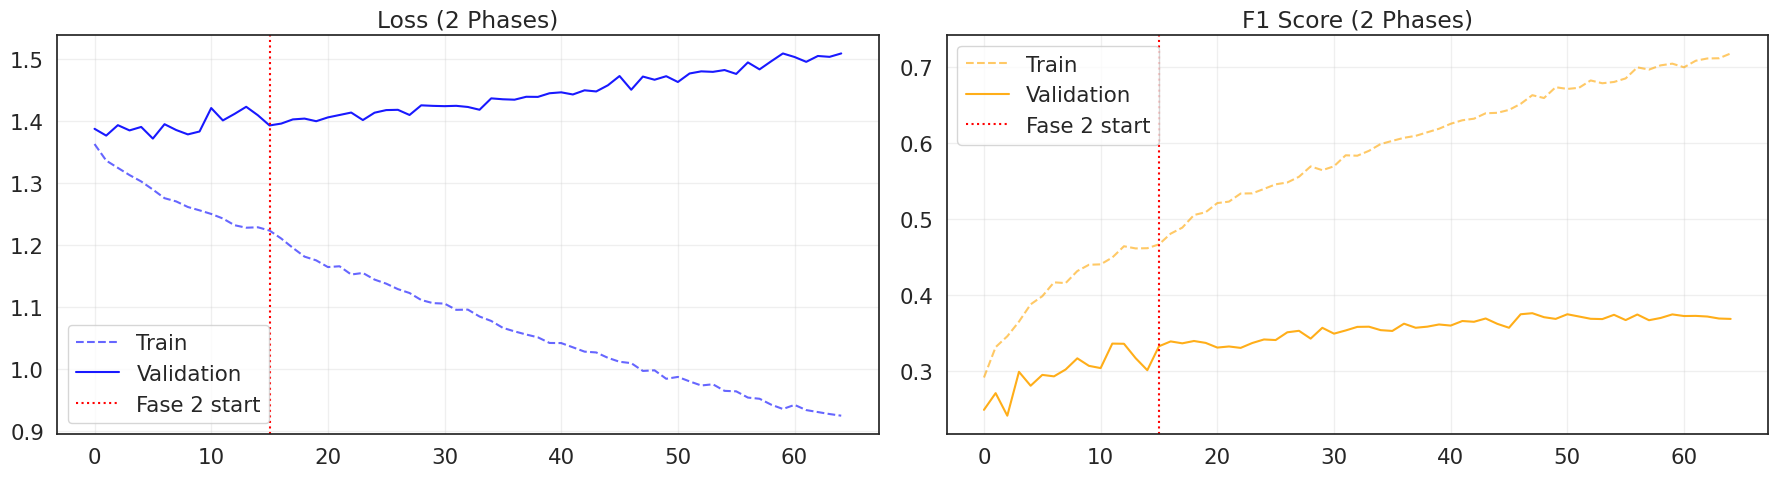


FINAL BEST VAL F1: 0.3763


In [49]:
combined_history = {
    'train_loss': history_phase1['train_loss'] + history_phase2['train_loss'],
    'val_loss': history_phase1['val_loss'] + history_phase2['val_loss'],
    'train_f1': history_phase1['train_f1'] + history_phase2['train_f1'],
    'val_f1': history_phase1['val_f1'] + history_phase2['val_f1']
}

# Plot finale
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Loss
ax1.plot(combined_history['train_loss'], label='Train', alpha=0.6, color='blue', linestyle='--')
ax1.plot(combined_history['val_loss'], label='Validation', alpha=0.9, color='blue')
ax1.axvline(x=len(history_phase1['train_loss']), color='red', linestyle=':', label='Fase 2 start')
ax1.set_title('Loss (2 Phases)')
ax1.legend()
ax1.grid(alpha=0.3)

# F1
ax2.plot(combined_history['train_f1'], label='Train', alpha=0.6, color='orange', linestyle='--')
ax2.plot(combined_history['val_f1'], label='Validation', alpha=0.9, color='orange')
ax2.axvline(x=len(history_phase1['train_f1']), color='red', linestyle=':', label='Fase 2 start')
ax2.set_title('F1 Score (2 Phases)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFINAL BEST VAL F1: {max(combined_history['val_f1']):.4f}")

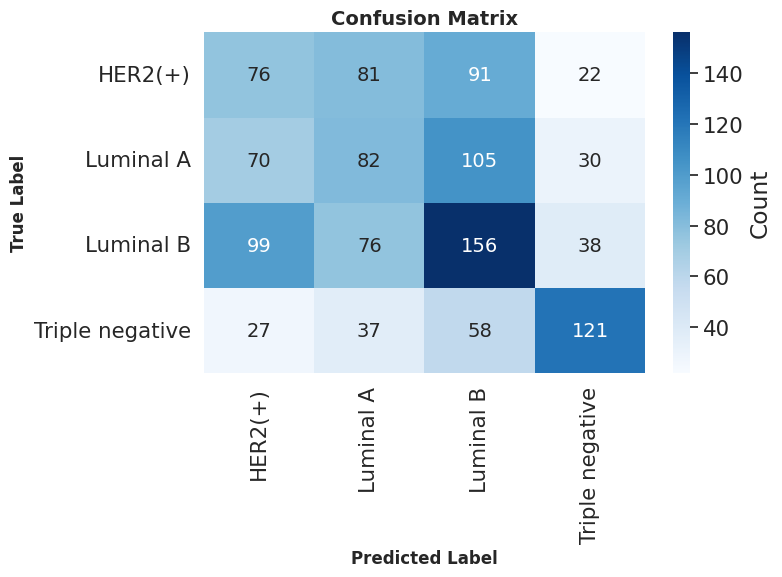

In [50]:
plot_confusion_matrix(best_model, val_loader, int_to_label)


## 🤯**Test Time Augmentation**

Creates 3 possible configurations:
1) flip H+V
2) flip H+V + rotations
3) flip H+V + rotations + regulation brightness/contrast

In [51]:
import torchvision.transforms.functional as F

def tta_pair(img, mask, mode="flip"):
    """
    Applica TTA a image + mask.
    img:  (B, 3, H, W)
    mask: (B, 1, H, W)
    """
    tta_imgs  = [img]
    tta_masks = [mask]

    # --- FLIP ---
    if mode in ["flip", "full", "full_bc"]:
        # Horizontal flip
        tta_imgs.append(torch.flip(img, dims=[3]))
        tta_masks.append(torch.flip(mask, dims=[3]))

        # Vertical flip
        tta_imgs.append(torch.flip(img, dims=[2]))
        tta_masks.append(torch.flip(mask, dims=[2]))

    # --- ROTATIONS ---
    if mode in ["full", "full_bc"]:
        for k in [1, 2, 3]:
            tta_imgs.append(torch.rot90(img,  k=k, dims=[2, 3]))
            tta_masks.append(torch.rot90(mask, k=k, dims=[2, 3]))

    # --- BRIGHTNESS/CONTRAST SOLO SULL'IMMAGINE ---
    if mode == "full_bc":
        augmented_imgs = []
        for im in tta_imgs:
            b = 1.0 + 0.1 * (torch.rand(1).item() - 0.5)
            c = 1.0 + 0.1 * (torch.rand(1).item() - 0.5)
            im2 = F.adjust_brightness(im, b)
            im2 = F.adjust_contrast(im2, c)
            augmented_imgs.append(im2)

        tta_imgs = augmented_imgs

    return tta_imgs, tta_masks


Evaluates TTA on validation

In [52]:
def evaluate_tta_on_val(model, val_loader, device, mode="flip"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, mb, yb in val_loader:
            xb = xb.to(device)
            mb = mb.to(device)
            yb = yb.to(device)

            imgs_tta, masks_tta = tta_pair(xb, mb, mode=mode)

            logits_sum = 0
            for x_tta, m_tta in zip(imgs_tta, masks_tta):
                logits_sum += model(x_tta, m_tta)

            logits = logits_sum / len(imgs_tta)
            preds  = logits.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.argmax(dim=1).cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return macro_f1


Tuning

In [53]:
modes = ["flip", "full", "full_bc"]
best_mode = None
best_score = -1.0

for m in modes:
    score = evaluate_tta_on_val(best_model, val_loader, device, mode=m)
    print(f"TTA mode {m}: macro-F1 = {score:.4f}")
    if score > best_score:
        best_score = score
        best_mode = m

print(f"\nBest TTA mode on validation: {best_mode} (macro-F1 = {best_score:.4f})")

TTA mode flip: macro-F1 = 0.3873
TTA mode full: macro-F1 = 0.3833
TTA mode full_bc: macro-F1 = 0.2545

Best TTA mode on validation: flip (macro-F1 = 0.3873)


## **🕹️ Use the Model - Make Inference**

In [54]:
from tqdm import tqdm
import numpy as np
import torch
from torch.utils.data import DataLoader
import os

def predict_test_set(model, test_dataset, test_filenames, int_to_label, device='cuda', batch_size=64,
                     aggregation='max_confidence', num_workers=4, tta_mode="none"):
    """
    Predicts classes of the test set created with HybridPatching

    Args:
        model: pretrained PyTorch model
        test_dataset: HybridPatchingDataset where labels=None
        test_filenames: ordered list of test filenames
        int_to_labels: dictionary to convert predictions

    Returns:
        final_predictions_ordered: array (N_filenames, ) ordered like test_filenames
        prediction_details: dictionary with details for analysis
    """
    model.eval()
    model.to(device)

    # DataLoader for patches
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True if device == 'cuda' else False
    )

    print(f"\n{'='*60}")
    print(f"TEST SET INFERENCE (CORRETTA)")
    print(f"{'='*60}")
    print(f"Total patches: {len(test_dataset)}")
    print(f"Test images: {len(test_filenames)}")
    print(f"Aggregation: {aggregation}")
    print(f"Device: {device}")
    print(f"{'='*60}\n")

    # predictions for each patch
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for patches, masks in tqdm(test_loader, desc="Processing patches"):
            patches = patches.to(device)
            masks = masks.to(device)

            # Apply TTA
            tta_imgs, tta_masks = tta_pair(patches, masks, mode=tta_mode)

            tta_probs = []
            for aug_img, aug_mask in zip(tta_imgs, tta_masks):
                outputs = model(aug_img, aug_mask)
                probs = torch.softmax(outputs, dim=1)
                tta_probs.append(probs)

            probs_mean = torch.stack(tta_probs, dim=0).mean(dim=0)
            predictions = torch.argmax(probs_mean, dim=1)

            all_predictions.append(predictions.cpu().numpy())
            all_probabilities.append(probs_mean.cpu().numpy())

    all_predictions = np.concatenate(all_predictions, axis=0)
    all_probabilities = np.concatenate(all_probabilities, axis=0)

    # Mapping
    patch_to_image = np.array([item['image_idx'] for item in test_dataset.patch_data])
    unique_images = np.unique(patch_to_image)

    image_to_filename_idx = {}
    for pos, fname in enumerate(test_filenames):
        img_num = int(fname.split("_")[1].split(".")[0])  # Estract index from filename
        image_to_filename_idx[img_num] = pos

    print(f"Mapping created: {len(image_to_filename_idx)} images mapped")

    # Aggregation
    n_images = len(test_filenames)
    final_predictions_ordered = np.full(n_images, -1, dtype=int)
    prediction_details = {
        'image_predictions': [], 'image_probabilities': [],
        'patches_per_image': [], 'confidence_scores': [],
        'image_indices': []  # (debug))
    }

    for img_idx in tqdm(unique_images, desc="Aggregating predictions"):
        mask = (patch_to_image == img_idx)
        img_predictions = all_predictions[mask]
        img_probabilities = all_probabilities[mask]

        if aggregation == 'soft_voting':
            avg_probs = np.mean(img_probabilities, axis=0)
            final_pred = np.argmax(avg_probs)
            confidence = np.max(avg_probs)
        elif aggregation == 'hard_voting':
            final_pred = np.bincount(img_predictions).argmax()
            confidence = np.sum(img_predictions == final_pred) / len(img_predictions)
            avg_probs = None
        elif aggregation == 'max_confidence':
            max_conf_idx = np.argmax(np.max(img_probabilities, axis=1))
            final_pred = img_predictions[max_conf_idx]
            confidence = np.max(img_probabilities[max_conf_idx])
            avg_probs = img_probabilities[max_conf_idx]

        # map to correct position
        filename_pos = image_to_filename_idx.get(img_idx, None)
        if filename_pos is not None:
            final_predictions_ordered[filename_pos] = final_pred
            prediction_details['image_predictions'].append(final_pred)
            prediction_details['image_probabilities'].append(avg_probs if 'avg_probs' in locals() else img_probabilities)
            prediction_details['patches_per_image'].append(len(img_predictions))
            prediction_details['confidence_scores'].append(confidence)
            prediction_details['image_indices'].append(img_idx)
        else:
            print(f"WARNING: image_idx {img_idx} not in test_filenames!")

    # check
    missing = np.sum(final_predictions_ordered == -1)
    if missing > 0:
        print(f"ERROR: {missing}/{n_images} immagini senza predizione!")
        print("Immagini mancanti:", np.where(final_predictions_ordered == -1))
    else:
        print(f"PERFETTO: {n_images}/{n_images} immagini mappate correttamente")

    # Debug mapping
    print("\n=== MAPPING DEBUG ==")
    print(f"First 5 mappings: img_idx -> filename_pos")
    for i in range(min(5, len(prediction_details['image_indices']))):
        print(f"  {prediction_details['image_indices'][i]} -> {image_to_filename_idx[prediction_details['image_indices'][i]]}")
    print(f"Last image_idx: {unique_images[-1]} -> pos {image_to_filename_idx.get(unique_images[-1], 'MISSING')}")
    print("===================\n")

    # Final stats
    print(f"\n{'='*60}")
    print(f"INFERENCE COMPLETE - READY FOR SUBMISSION")
    print(f"{'='*60}")
    print(f"Images predicted: {n_images}")
    print(f"Avg patches/image: {np.mean(prediction_details['patches_per_image']):.1f}")
    print(f"Avg confidence: {np.mean(prediction_details['confidence_scores']):.3f}")
    print(f"Missing predictions: {missing}")
    print(f"{'='*60}\n")

    return final_predictions_ordered, prediction_details


def save_predictions(predictions, test_filenames, int_to_label, output_path='submission.csv'):
    """
    Save predictions in CSV

    Args:
        predictions: array (N,) with indexes of the predicted class
        test_filenames: list of filenames of test images
        int_to_label: dictionary to map indexes to label strings dict
        output_path: path of output CSV
    """
    import csv

    # Convert indexes to label string
    predicted_labels = [int_to_label[int(p)] for p in predictions]

    with open(output_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["sample_index", "label"])

        for fname, label in zip(test_filenames, predicted_labels):
            writer.writerow([fname, label])

    print(f"\n{'='*60}")
    print(f"SUBMISSION FILE CREATED")
    print(f"{'='*60}")
    print(f"File: {output_path}")
    print(f"Total predictions: {len(predictions)}")
    print(f"\nLabel distribution:")
    for lbl in set(predicted_labels):
        count = predicted_labels.count(lbl)
        print(f"  {lbl}: {count} ({100*count/len(predicted_labels):.1f}%)")
    print(f"\nFirst 5 entries:")
    for i in range(min(5, len(test_filenames))):
        print(f"  {test_filenames[i]} -> {predicted_labels[i]}")
    print(f"{'='*60}\n")


def analyze_predictions(prediction_details, save_path='prediction_analysis.png'):
    """
    Visuals to analyze predictions

    Args:
        prediction_details: dict returned by predict_test_set
        save_path: path to save the plot
    """
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Patch distribution per image
    ax = axes[0, 0]
    patches_per_img = prediction_details['patches_per_image']
    ax.hist(patches_per_img, bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Number of patches')
    ax.set_ylabel('Number of images')
    ax.set_title(f'Patches per Image Distribution\n(mean={np.mean(patches_per_img):.1f})')
    ax.grid(True, alpha=0.3)

    # Confidence scores distributions
    ax = axes[0, 1]
    confidence = prediction_details['confidence_scores']
    ax.hist(confidence, bins=30, edgecolor='black', alpha=0.7, color='green')
    ax.set_xlabel('Confidence score')
    ax.set_ylabel('Number of images')
    ax.set_title(f'Prediction Confidence Distribution\n(mean={np.mean(confidence):.3f})')
    ax.axvline(np.mean(confidence), color='red', linestyle='--', label='Mean')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Predicted classes distribution
    ax = axes[1, 0]
    predictions = prediction_details['image_predictions']
    unique_classes = np.unique(predictions)
    class_counts = [np.sum(np.array(predictions) == c) for c in unique_classes]
    ax.bar(unique_classes, class_counts, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Class')
    ax.set_ylabel('Number of images')
    ax.set_title('Predicted Class Distribution')
    ax.set_xticks(unique_classes)
    ax.grid(True, alpha=0.3, axis='y')

    # 4. Confidence vs Patches per image
    ax = axes[1, 1]
    ax.scatter(patches_per_img, confidence, alpha=0.5, s=20)
    ax.set_xlabel('Number of patches')
    ax.set_ylabel('Confidence score')
    ax.set_title('Confidence vs Number of Patches')
    ax.grid(True, alpha=0.3)

    # Correlation
    corr = np.corrcoef(patches_per_img, confidence)[0, 1]
    ax.text(0.05, 0.95, f'Correlation: {corr:.3f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\nAnalysis plot saved to: {save_path}")
    plt.close()

In [55]:
test_folder = "/content/test_data"

test_filenames = []
for filename in os.listdir(test_folder):
    if filename.lower().startswith("img"):
        test_filenames.append(filename)
test_filenames = sorted(test_filenames, key=lambda x: int(x.split("_")[1].split(".")[0]))

predictions, details = predict_test_set(
    best_model,
    test_dataset,
    test_filenames,
    int_to_label,
    device=device,
    batch_size=64,
    aggregation='soft_voting',
    tta_mode="flip"
)

save_predictions(
    predictions=predictions,
    test_filenames=test_filenames,
    int_to_label=int_to_label,
    output_path='submission.csv'
)


TEST SET INFERENCE (CORRETTA)
Total patches: 4293
Test images: 477
Aggregation: soft_voting
Device: cuda



Processing patches: 100%|██████████| 68/68 [00:11<00:00,  5.83it/s]


Mapping created: 477 images mapped


Aggregating predictions: 100%|██████████| 477/477 [00:00<00:00, 14242.88it/s]


PERFETTO: 477/477 immagini mappate correttamente

=== MAPPING DEBUG ==
First 5 mappings: img_idx -> filename_pos
  0 -> 0
  1 -> 1
  2 -> 2
  3 -> 3
  4 -> 4
Last image_idx: 476 -> pos 476


INFERENCE COMPLETE - READY FOR SUBMISSION
Images predicted: 477
Avg patches/image: 9.0
Avg confidence: 0.405
Missing predictions: 0


SUBMISSION FILE CREATED
File: submission.csv
Total predictions: 477

Label distribution:
  HER2(+): 133 (27.9%)
  Luminal A: 100 (21.0%)
  Triple negative: 26 (5.5%)
  Luminal B: 218 (45.7%)

First 5 entries:
  img_0000.png -> Luminal B
  img_0001.png -> Luminal B
  img_0002.png -> Luminal A
  img_0003.png -> Triple negative
  img_0004.png -> HER2(+)

